
📌 DATASET COLUMNS:
['team_1', 'team_2', 'winner', 'margin', 'ground', 'match_date', 'scorecard', 'format', 'toss_winner', 'toss_decision', 'toss_decision']

✅ RENAMED COLUMNS (AFTER REMOVING DUPLICATES):
['team1', 'team2', 'winner', 'margin', 'venue', 'match_date', 'scorecard', 'format', 'toss_winner', 'toss_decision']

📊 BASIC EDA - DATA INFO:
<class 'pandas.core.frame.DataFrame'>
Index: 6755 entries, 2 to 7792
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   team1          6755 non-null   object
 1   team2          6755 non-null   object
 2   winner         6755 non-null   object
 3   margin         6755 non-null   object
 4   venue          6755 non-null   object
 5   match_date     6755 non-null   object
 6   scorecard      6755 non-null   object
 7   format         6755 non-null   object
 8   toss_winner    6755 non-null   object
 9   toss_decision  6755 non-null   object
dtypes: object(10)
memory usage: 5

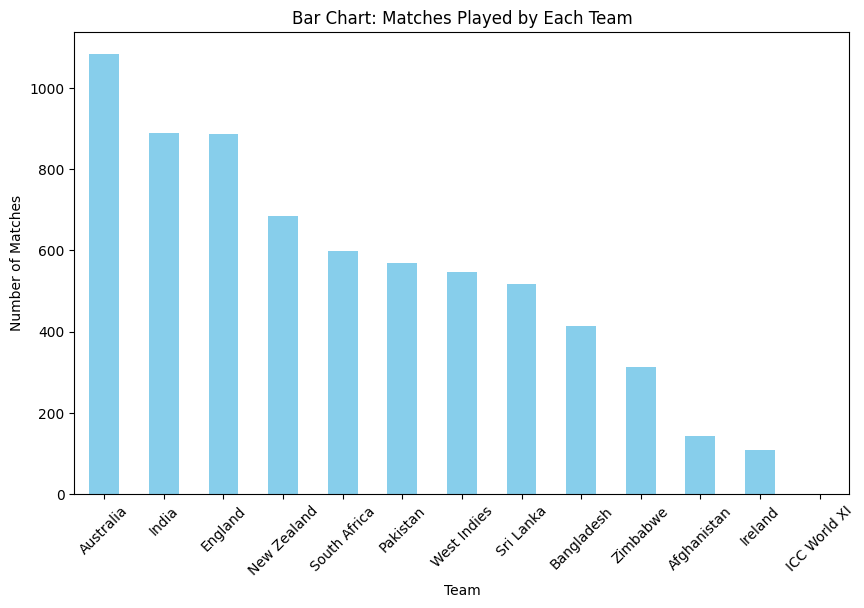

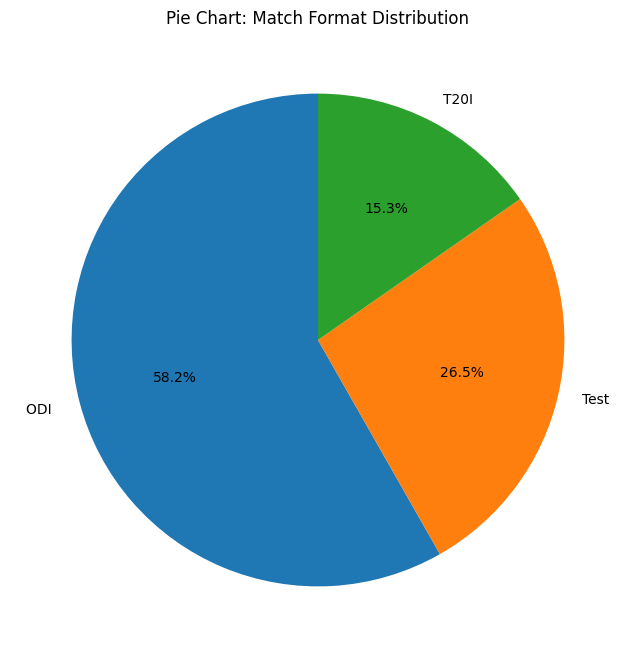

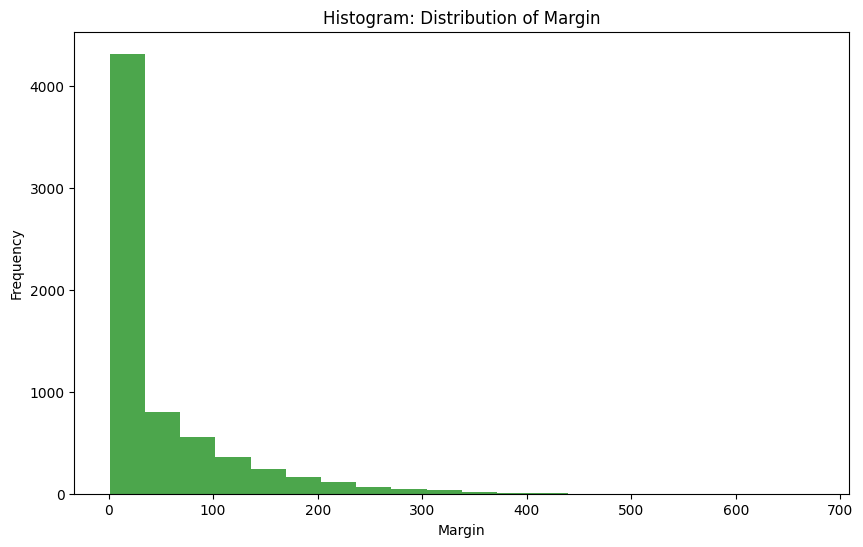

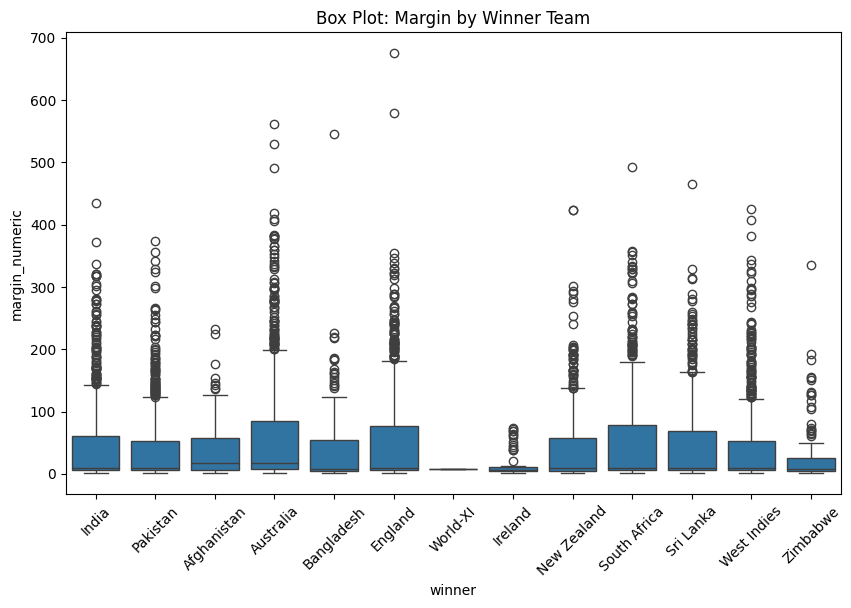

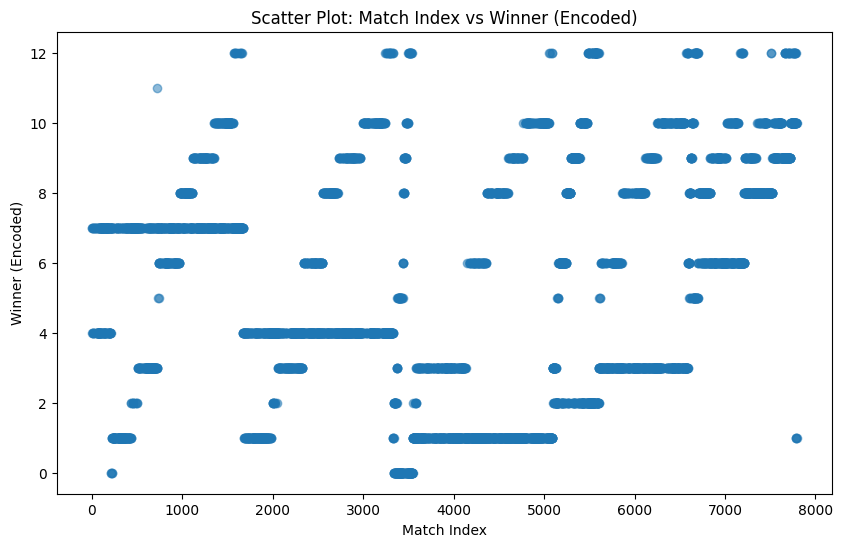

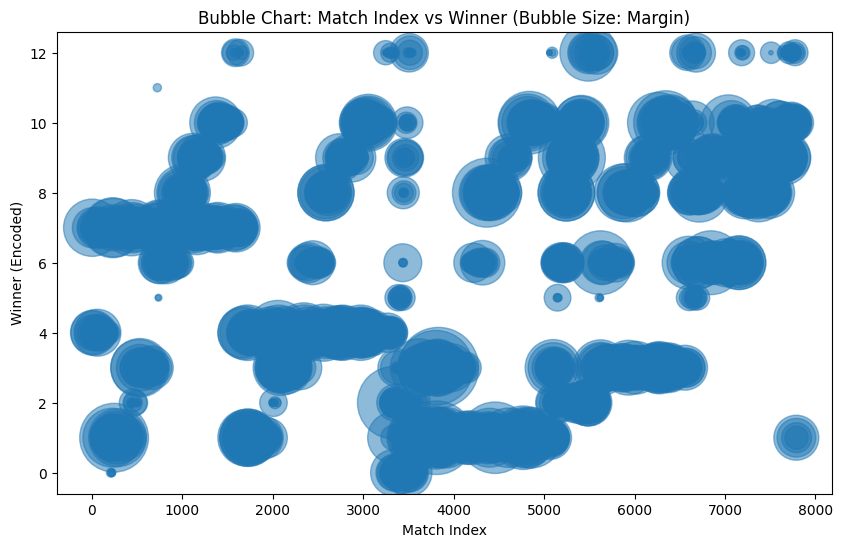

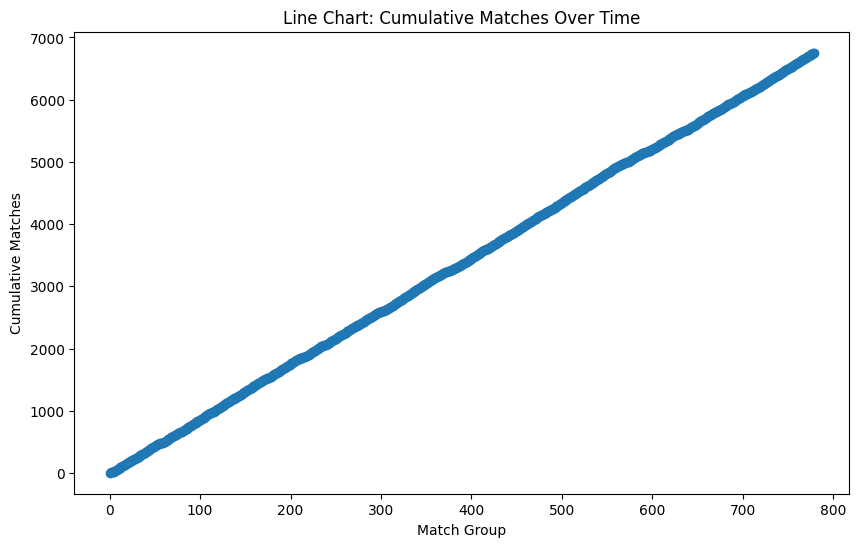

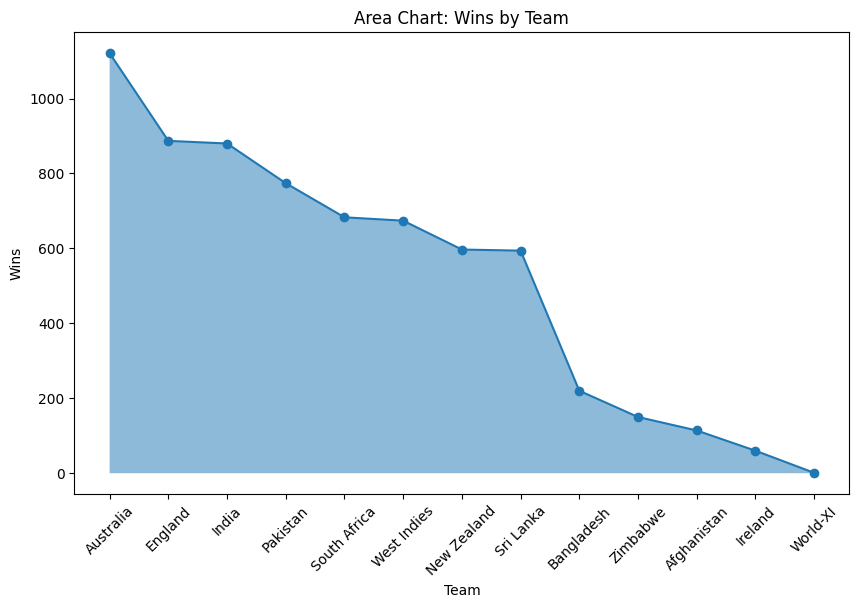

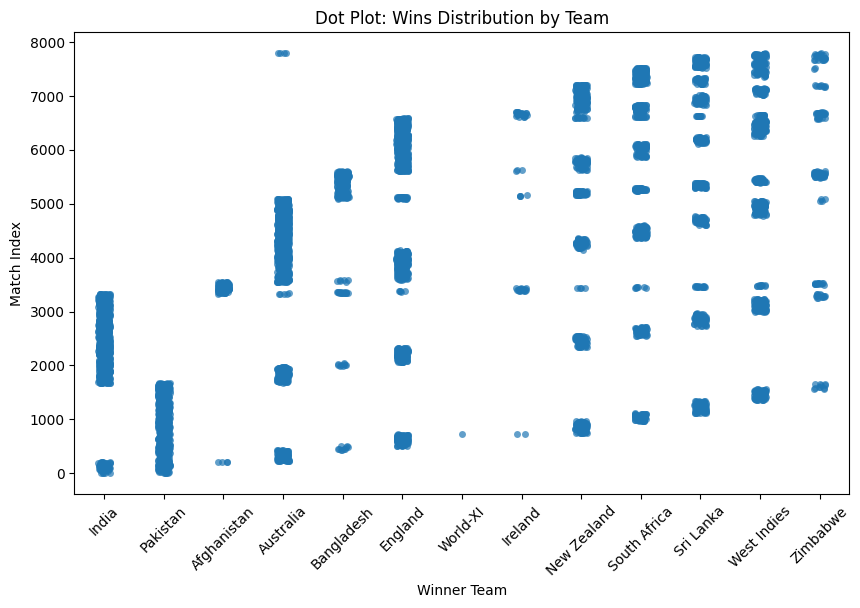


📊 FEATURES USED: ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue']

📊 CLASS DISTRIBUTION BEFORE BALANCING:
winner
1     1121
3      887
4      880
7      774
8      683
10     674
6      597
9      594
2      220
12     150
0      114
5       60
11       1
Name: count, dtype: int64

❌ SMOTE failed: Expected n_neighbors <= n_samples_fit, but n_neighbors = 6, n_samples_fit = 1, n_samples = 1. Using basic oversampling as alternative.

✅ Basic oversampling applied as alternative to SMOTE.

📊 CLASS DISTRIBUTION AFTER BALANCING:
winner
1     1121
4     1121
7     1121
0     1121
2     1121
3     1121
11    1121
5     1121
6     1121
8     1121
9     1121
10    1121
12    1121
Name: count, dtype: int64


c:\Users\dell\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



🎯 Random Forest Accuracy: 0.7385934819897084

📄 Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.81       242
           1       0.61      0.64      0.62       233
           2       0.71      0.81      0.76       208
           3       0.68      0.70      0.69       217
           4       0.71      0.57      0.63       228
           5       0.79      0.90      0.84       259
           6       0.82      0.67      0.74       235
           7       0.74      0.62      0.68       224
           8       0.76      0.80      0.78       219
           9       0.66      0.65      0.66       205
          10       0.69      0.71      0.70       209
          11       1.00      1.00      1.00       219
          12       0.63      0.66      0.65       217

    accuracy                           0.74      2915
   macro avg       0.74      0.74      0.73      2915
weighted avg       0.74      0.74      0.74    

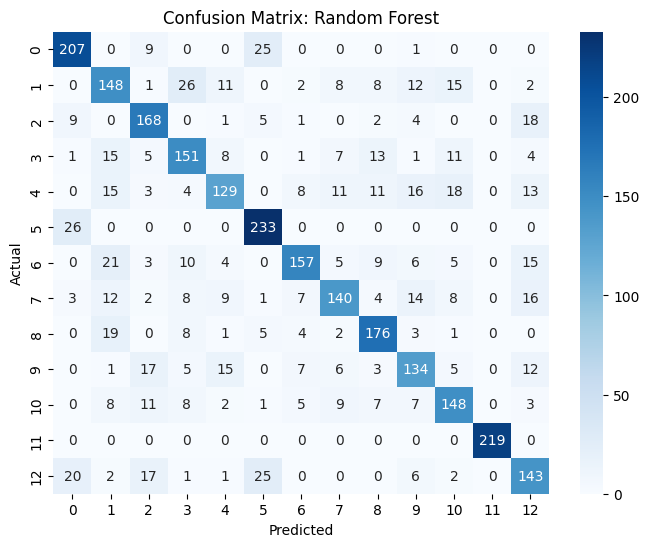

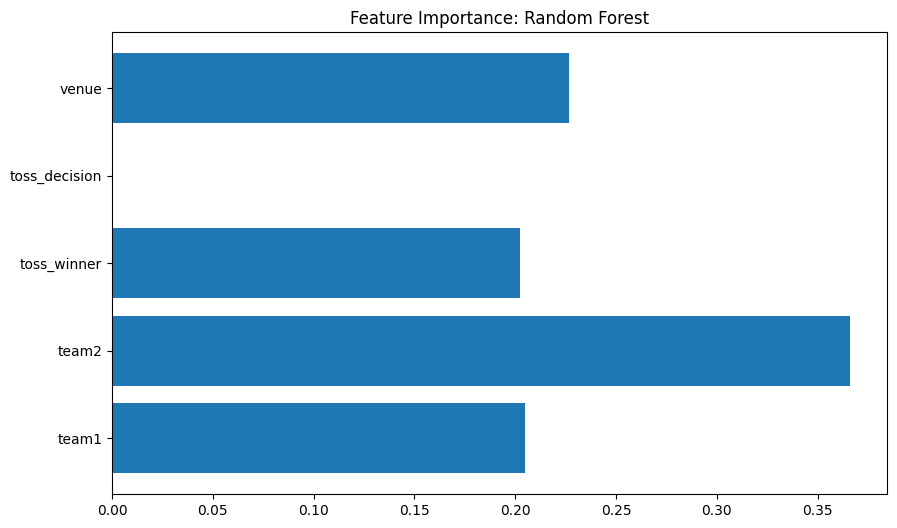

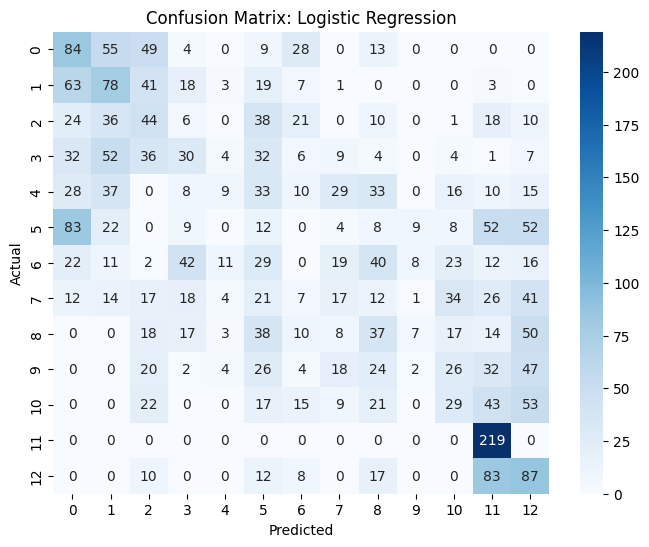

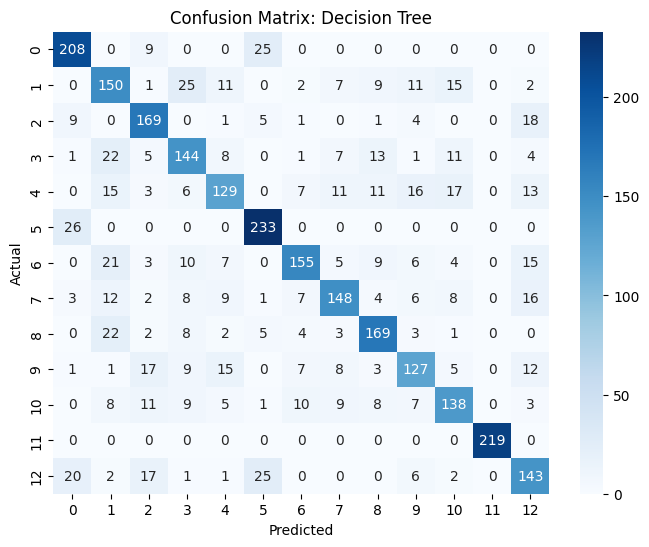

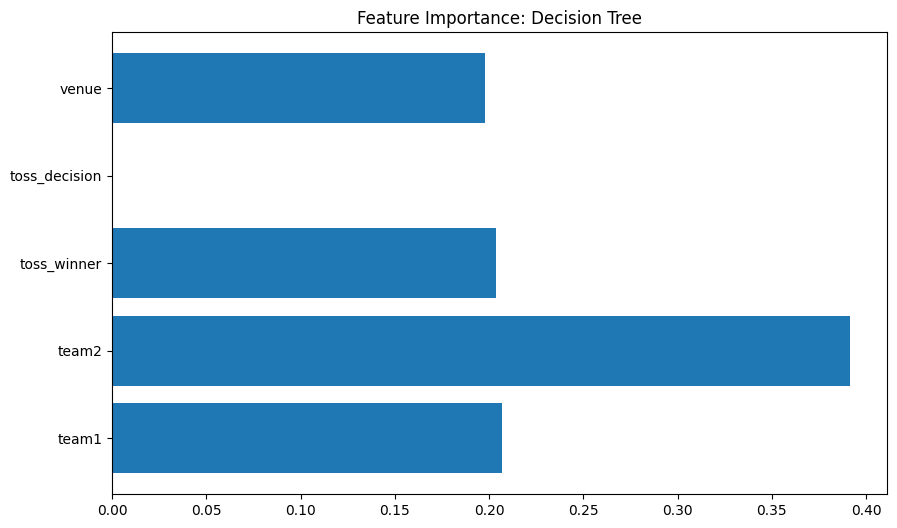

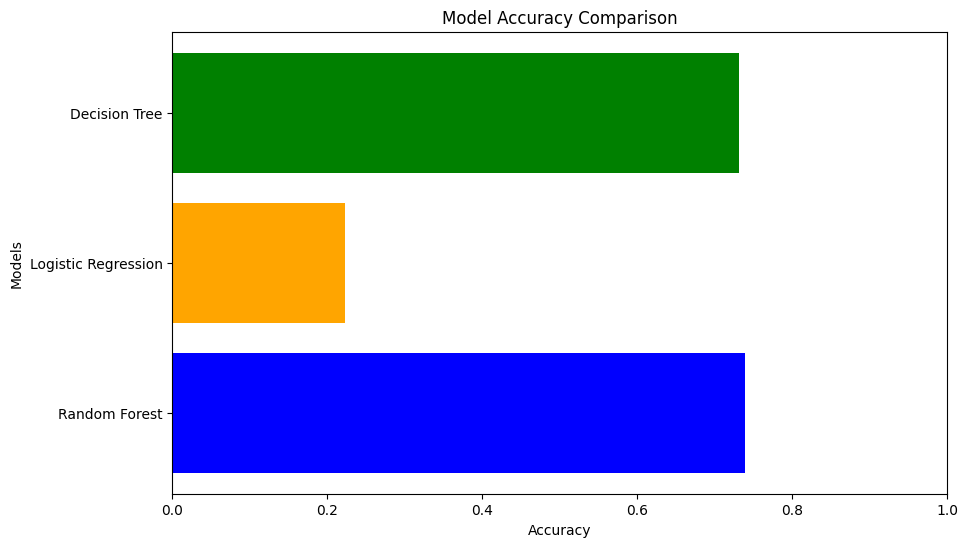


✅ MODELS SAVED SUCCESSFULLY!


In [1]:
# =====================================================
# CRICKET MATCH OUTCOME PREDICTION - AI PROJECT
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression  # Added for multiple models
from sklearn.tree import DecisionTreeClassifier  # Added for Decision Tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample  # For basic oversampling as alternative to SMOTE

# Install imblearn if not already installed: Run 'pip install imbalanced-learn' in your terminal
try:
    from imblearn.over_sampling import SMOTE  # Added for class balancing
    use_smote = True
except ImportError:
    print("❌ imblearn not installed. Using basic oversampling as alternative.")
    use_smote = False

# =====================================================
# 1. FIELD SELECTION
# =====================================================
# Field: Sports Analytics (Cricket)

# =====================================================
# 2. NARROW DOWN THE INTERESTING TOPIC OF THAT FIELD
# =====================================================
# Topic: Predicting cricket match outcomes (winner) based on teams, venues, and other factors.

# =====================================================
# 3. DATASET/S SELECTION
# =====================================================
# Updated dataset path as per user request
data = pd.read_csv("D:\\AI codes\\Cricket-all-teams-all-matches-randomized.csv")

# =====================================================
# 4. PRE-PROCESSING AND EDA STEPS
# =====================================================
# Clean column names
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_")

print("\n📌 DATASET COLUMNS:")
print(data.columns.tolist())

# Auto column mapping
rename_map = {}
for col in data.columns:
    if "team1" in col or "team_1" in col or "home" in col:
        rename_map[col] = "team1"
    elif "team2" in col or "team_2" in col or "away" in col:
        rename_map[col] = "team2"
    elif "toss" in col and "winner" in col:
        rename_map[col] = "toss_winner"
    elif "toss" in col and "decision" in col:
        rename_map[col] = "toss_decision"
    elif "venue" in col or "ground" in col or "stadium" in col:
        rename_map[col] = "venue"
    elif "winner" in col and col != "toss_winner":
        rename_map[col] = "winner"

data.rename(columns=rename_map, inplace=True)

# Handle duplicate columns (e.g., two 'toss_decision' columns)
data = data.loc[:, ~data.columns.duplicated()]

print("\n✅ RENAMED COLUMNS (AFTER REMOVING DUPLICATES):")
print(data.columns.tolist())

# Drop NA
data.dropna(inplace=True)

# EDA: Basic statistics
print("\n📊 BASIC EDA - DATA INFO:")
print(data.info())
print("\n📊 BASIC EDA - DESCRIBE:")
print(data.describe(include='all'))

# EDA: Check for missing values
print("\n📊 BASIC EDA - MISSING VALUES:")
print(data.isnull().sum())

# EDA: Correlation (only numeric columns)
numeric_cols = data.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    print("\n📊 BASIC EDA - CORRELATION MATRIX:")
    print(data[numeric_cols].corr())
else:
    print("\n📊 BASIC EDA - No numeric columns for correlation.")

# =====================================================
# 5. DATA VISUALIZATION (UNDERSTANDING OF DATASET)
# =====================================================
# Prepare data_viz for visualizations
data_viz = data.copy()

# Encoding for data (but keep data_viz original for plots)
categorical_cols = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']
label_encoders = {}
for col in categorical_cols:
    if col in data.columns:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le
        data_viz[col] = le.inverse_transform(data[col])  # For readable plots
    else:
        print(f"❌ Missing column: {col}")

# Prepare margin_numeric if needed (fixed regex escape sequence)
if 'margin' in data_viz.columns:
    data_viz['margin_numeric'] = data_viz['margin'].str.extract(r'(\d+)').astype(float)

# Visualization 1: Bar Chart
plt.figure(figsize=(10, 6))
data_viz['team1'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Bar Chart: Matches Played by Each Team')
plt.xlabel('Team')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.show()

# Visualization 2: Pie Chart
plt.figure(figsize=(8, 8))
data_viz['format'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Pie Chart: Match Format Distribution')
plt.ylabel('')
plt.show()

# Visualization 3: Histogram
plt.figure(figsize=(10, 6))
if 'margin' in data_viz.columns:
    data_viz['margin_numeric'].plot(kind='hist', bins=20, color='green', alpha=0.7)
    plt.title('Histogram: Distribution of Margin')
    plt.xlabel('Margin')
    plt.ylabel('Frequency')
else:
    plt.text(0.5, 0.5, 'Margin column not available', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Histogram: Margin (N/A)')
plt.show()

# Visualization 4: Box Plot
plt.figure(figsize=(10, 6))
if 'margin' in data_viz.columns:
    sns.boxplot(x='winner', y='margin_numeric', data=data_viz)
    plt.title('Box Plot: Margin by Winner Team')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'Margin column not available', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Box Plot: Margin by Winner (N/A)')
plt.show()

# Visualization 5: Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(data.index, data['winner'], alpha=0.5)
plt.title('Scatter Plot: Match Index vs Winner (Encoded)')
plt.xlabel('Match Index')
plt.ylabel('Winner (Encoded)')
plt.show()

# Visualization 6: Bubble Chart
plt.figure(figsize=(10, 6))
if 'margin' in data_viz.columns:
    plt.scatter(data.index, data['winner'], s=data_viz['margin_numeric']*5, alpha=0.5)
    plt.title('Bubble Chart: Match Index vs Winner (Bubble Size: Margin)')
    plt.xlabel('Match Index')
    plt.ylabel('Winner (Encoded)')
else:
    plt.text(0.5, 0.5, 'Margin column not available', ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Bubble Chart: Match Index vs Winner (N/A)')
plt.show()

# Visualization 7: Line Chart
plt.figure(figsize=(10, 6))
wins_cumsum = data_viz.groupby(data.index // 10)['winner'].count().cumsum()
plt.plot(wins_cumsum.index, wins_cumsum.values, marker='o')
plt.title('Line Chart: Cumulative Matches Over Time')
plt.xlabel('Match Group')
plt.ylabel('Cumulative Matches')
plt.show()

# Visualization 8: Area Chart
plt.figure(figsize=(10, 6))
wins = data_viz['winner'].value_counts()
plt.fill_between(wins.index, wins.values, alpha=0.5)
plt.plot(wins.index, wins.values, marker='o')
plt.title('Area Chart: Wins by Team')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.show()

# Visualization 9: Dot Plot
plt.figure(figsize=(10, 6))
sns.stripplot(x='winner', y=data.index, data=data_viz, jitter=True, alpha=0.7)
plt.title('Dot Plot: Wins Distribution by Team')
plt.xlabel('Winner Team')
plt.ylabel('Match Index')
plt.xticks(rotation=45)
plt.show()

# =====================================================
# 6. FEATURE SELECTION / ENGINEERING
# =====================================================
features = []
for f in ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'runs', 'wickets', 'overs']:
    if f in data.columns:
        features.append(f)

print("\n📊 FEATURES USED:", features)

X = data[features]
y = data['winner']

# =====================================================
# 7. CLASS BALANCING
# =====================================================
# Check class distribution
print("\n📊 CLASS DISTRIBUTION BEFORE BALANCING:")
print(y.value_counts())

if use_smote:
    try:
        # Apply SMOTE for balancing
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X, y)
        print("\n✅ SMOTE applied for class balancing.")
    except ValueError as e:
        print(f"\n❌ SMOTE failed: {e}. Using basic oversampling as alternative.")
        use_smote = False  # Fall back to basic

if not use_smote:
    # Alternative: Basic oversampling using sklearn
    # Combine X and y for resampling
    data_combined = pd.concat([X, y], axis=1)
    majority_class_value = y.value_counts().idxmax()
    majority_class = data_combined[data_combined['winner'] == majority_class_value]
    minority_classes = [cls for cls in y.unique() if cls != majority_class_value]

    # Oversample minority classes to match majority
    balanced_data = [majority_class]
    for cls in minority_classes:
        minority_class = data_combined[data_combined['winner'] == cls]
        minority_oversampled = resample(minority_class, replace=True, n_samples=len(majority_class), random_state=42)
        balanced_data.append(minority_oversampled)

    # Combine and split back
    balanced_df = pd.concat(balanced_data)
    X_balanced = balanced_df.drop('winner', axis=1)
    y_balanced = balanced_df['winner']
    print("\n✅ Basic oversampling applied as alternative to SMOTE.")

print("\n📊 CLASS DISTRIBUTION AFTER BALANCING:")
print(pd.Series(y_balanced).value_counts())

# =====================================================
# 8. NORMALIZATION OF BALANCED, PREPROCESSED DATASET
# =====================================================
scaler = StandardScaler()
X_balanced_normalized = scaler.fit_transform(X_balanced)

# =====================================================
# 9. DATA-SPLITTING (TRAINING AND TESTING SUB-SETS)
# =====================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced_normalized, y_balanced, test_size=0.2, random_state=42
)

# =====================================================
# 10. MODELS TRAINING (ML MODELS OR DL MODELS)
# =====================================================
# Model 1: Random Forest
model_rf = RandomForestClassifier(n_estimators=300, random_state=42)
model_rf.fit(X_train, y_train)

# Model 2: Logistic Regression (for comparison)
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)

# Model 3: Decision Tree (added as requested)
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)

# =====================================================
# 11. MODEL EVALUATION
# =====================================================
# Evaluate Random Forest
y_pred_rf = model_rf.predict(X_test)
print("\n🎯 Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n📄 Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

# Evaluate Logistic Regression
y_pred_lr = model_lr.predict(X_test)
print("\n🎯 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\n📄 Logistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

# Evaluate Decision Tree
y_pred_dt = model_dt.predict(X_test)
print("\n🎯 Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\n📄 Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))

# =====================================================
# 12. RESULTS VISUALIZATIONS
# =====================================================
# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance for Random Forest
importances_rf = model_rf.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(features, importances_rf)
plt.title("Feature Importance: Random Forest")
plt.show()

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature Importance for Decision Tree
importances_dt = model_dt.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(features, importances_dt)
plt.title("Feature Importance: Decision Tree")
plt.show()

# =====================================================
# MODEL ACCURACY COMPARISON (HORIZONTAL BAR CHART)
# =====================================================
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)

models = ['Random Forest', 'Logistic Regression', 'Decision Tree']
accuracies = [acc_rf, acc_lr, acc_dt]

plt.figure(figsize=(10, 6))
plt.barh(models, accuracies, color=['blue', 'orange', 'green'])
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.xlim(0, 1)  # Assuming accuracy is between 0 and 1
plt.show()

# =====================================================
# SAVE MODEL
# =====================================================
joblib.dump(model_rf, "cricket_match_prediction_model_rf.pkl")
joblib.dump(model_lr, "cricket_match_prediction_model_lr.pkl")
joblib.dump(model_dt, "cricket_match_prediction_model_dt.pkl")  # Added for Decision Tree
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

print("\n✅ MODELS SAVED SUCCESSFULLY!")